<a href="https://colab.research.google.com/github/ChariteshReddyPatlolla/stock-price-predector/blob/main/try_stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

df=yf.download("RELIANCE.NS",period='60d',interval='5m')
df.index = df.index.tz_convert('Asia/Kolkata')

[*********************100%***********************]  1 of 1 completed


In [ ]:
df.shape

(4464, 5)

In [ ]:
# df.tail(20)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df=df[['Close']]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

In [ ]:
scaled_data.shape

(4464, 1)

In [ ]:
df=df['Close']

In [ ]:
df.head()

Ticker,RELIANCE.NS
Datetime,
2025-04-07 09:15:00+05:30,1132.800049
2025-04-07 09:20:00+05:30,1147.000000
2025-04-07 09:25:00+05:30,1149.599976
2025-04-07 09:30:00+05:30,1152.449951
2025-04-07 09:35:00+05:30,1143.699951


In [ ]:
import numpy as np

def seq(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i + timestep])
    return np.array(X), np.array(y)

X, y = seq(scaled_data, timestep=10)



In [ ]:
y.shape

(4454, 1)

In [ ]:
test_size=0.2
train_size=int(len(X)*(1-test_size))
X_train=X[:train_size]
y_train=y[:train_size]
X_test=X[train_size:]
y_test=y[train_size:]


In [ ]:
y_test.shape

(891, 1)

In [ ]:
import tensorflow as tf
import tensorflow.keras.layers as layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM


In [ ]:
model=Sequential()
model.add(LSTM(units=64,return_sequences=True,input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=32))
model.add(Dense(units=16,activation='relu'))
model.add(Dense(units=1))

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')


In [ ]:
history=model.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0720
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.5292e-04
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.4787e-04
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2839e-04
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3109e-04
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4169e-04
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2567e-04
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.5052e-04
Epoch 9/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.2037e-04
Epoch 10/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1297e-04


In [ ]:
predicted=model.predict(X_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


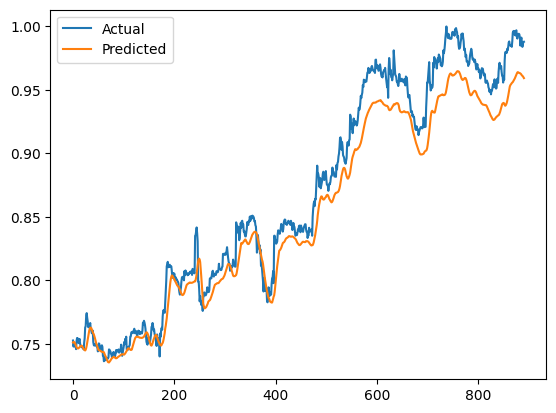

In [ ]:
import matplotlib.pyplot as plt
plt.plot(y_test,label='Actual')
plt.plot(predicted,label='Predicted')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Make sure test input shape is correct (reshape if necessary)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Number of future steps to predict
future_steps = 200

# Start with the last available sequence
last_sequence = X_test[-1]  # shape: (10,)
input_seq = last_sequence.reshape(1, 10, 1)

predictions = []

for _ in range(future_steps):
    pred_scaled = model.predict(input_seq, verbose=0)[0]  # shape (1,) if Dense(1)
    predictions.append(pred_scaled[0])  # save scalar

    # Append prediction to current input, remove first timestep
    next_input = np.append(input_seq[:, 1:, :], [[[pred_scaled[0]]]], axis=1)
    input_seq = next_input


In [ ]:
# Convert list to array
predictions_scaled = np.array(predictions).reshape(-1, 1)

# Inverse transform to original price
predicted_prices = scaler.inverse_transform(predictions_scaled)


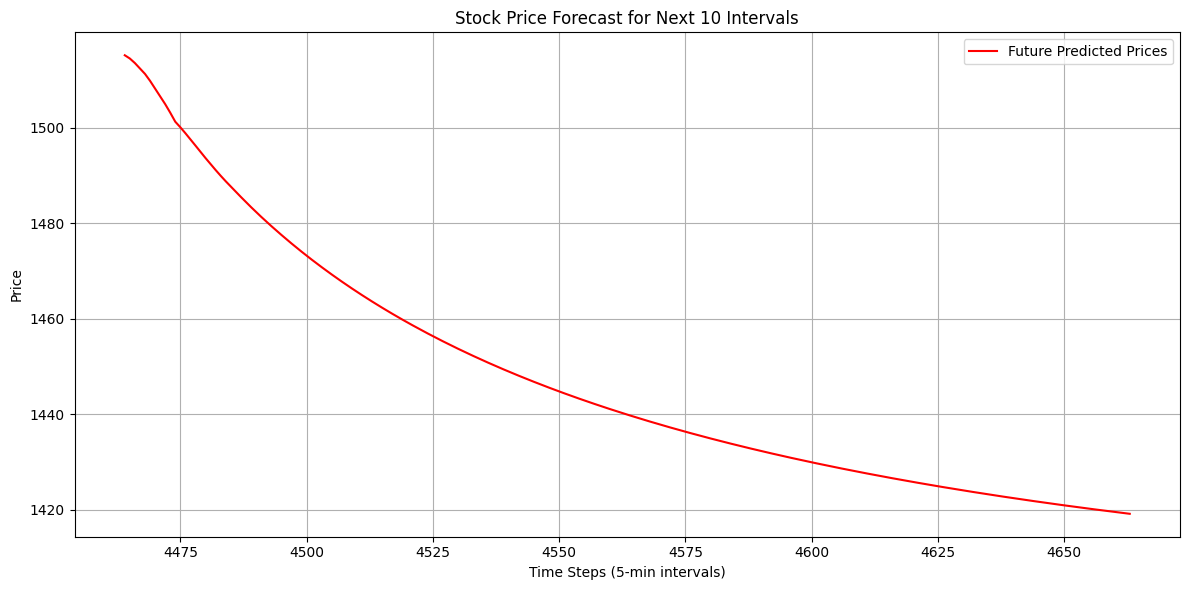

In [ ]:
# Plot full close price history
plt.figure(figsize=(12, 6))
# plt.plot(df.values, label="Original Close Price", color='blue')

# Plot future predictions starting after the last point
start_index = len(df)
future_index = range(start_index, start_index + future_steps)

plt.plot(future_index, predicted_prices, label="Future Predicted Prices", color='red')

plt.title("Stock Price Forecast for Next 10 Intervals")
plt.xlabel("Time Steps (5-min intervals)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
